
## Level 2 Task 1: Regression Interpretation

### Objective
Examine whether posting hour and hashtag count can predict the number of likes a post receives, using linear regression with an 80/20 train/test split.

### Results

| Model | Feature(s) | Slope | Train R² | Test R² | Test MSE |
|---|---|---|---|---|---|
| Simple regression 1 | Hour | 0.7477 | 0.0476 | -0.0236 | 210.19 |
| Simple regression 2 | Hashtags_count | 0.0000 | 0.0000 | -0.0050 | 231.83 |
| Multiple regression | Hour + Hashtags_count | 0.8798 (Hour) | 0.0695 | -0.0860 | 250.52 |

### Interpretation

**1. Posting hour vs likes.** The model suggests that each later hour of posting is associated with about 0.75 more likes, which is roughly 17 more likes between hour 0 and hour 23. The correlation between Hour and Likes is 0.195, a weak positive relationship. However, the model explains only about 4.8% of the variance in training data, and the test R² is negative (-0.0236). That means it predicts new data no better than simply guessing the average number of likes. Posting hour alone is therefore not a reliable predictor of likes.

**2. Hashtag count vs likes.** Every post in this dataset has exactly two hashtags, so `Hashtags_count` is constant. A constant feature has no variation to learn from, which is why the slope and R² are both 0.0000 and its correlation with other variables is undefined (NaN). This result does **not** show that hashtags have no effect on likes. It shows that this dataset cannot answer that question.

**3. Multiple regression (Hour + Hashtags_count).** Training R² rose slightly to 0.0695, but test R² dropped to -0.0860 and test MSE increased. Since Hashtags_count is constant, it adds no information, so this model is effectively the Hour model. The small training gain comes from the Hour feature, and the poor test score shows the model does not generalize.

### Limitations
- The hashtag feature has no variation, so its effect could not be measured.
- The Hour model used `random_state=42`, while the other two models used `random_state=30`. The models were therefore tested on different subsets of data, so the metrics are indicative rather than strictly comparable.
- Only linear relationships were tested, using a small number of features.

### Conclusion
Neither posting hour nor hashtag count is a useful linear predictor of likes in this dataset. Future work could add features that vary, such as retweets, sentiment, platform, or day of week, and could test non-linear models.

In [1]:
import pandas as pd
import os

In [2]:
df_sentiment=pd.read_csv("Sentiment dataset.csv")
df_sentiment["Hashtags_count"]=df_sentiment["Hashtags"].fillna("").str.count("#")
df_sentiment.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Hashtags_count
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,2
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,2
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,2
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,2
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,2


In [3]:
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0.1    732 non-null    int64  
 1   Unnamed: 0      732 non-null    int64  
 2   Text            732 non-null    object 
 3   Sentiment       732 non-null    object 
 4   Timestamp       732 non-null    object 
 5   User            732 non-null    object 
 6   Platform        732 non-null    object 
 7   Hashtags        732 non-null    object 
 8   Retweets        732 non-null    float64
 9   Likes           732 non-null    float64
 10  Country         732 non-null    object 
 11  Year            732 non-null    int64  
 12  Month           732 non-null    int64  
 13  Day             732 non-null    int64  
 14  Hour            732 non-null    int64  
 15  Hashtags_count  732 non-null    int64  
dtypes: float64(2), int64(7), object(7)
memory usage: 91.6+ KB


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

#Define Features (X) and Target (y)
x=df_sentiment[["Hour"]] #Double bracket keep X as 2D Dtafeame
y=df_sentiment["Likes"]

#Split Dataset into Training(80%) and Testing(20%)
x_train,x_test,y_train,y_test=train_test_split(
    x,y, test_size=0.2,random_state=42
)

#Fit Linear Regression Model
model=LinearRegression()
model.fit(x_train,y_train)

#Make Predictions
y_train_pred=model.predict(x_train)
y_test_pred=model.predict(x_test)

#Model Evaluation Metrics
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

print(f"Intercept (beta_0):{model.intercept_:.4f}")
print(f"Slope (beta_1): {model.coef_[0]:.4f}\n")

print(f"Train MSE:{train_mse:4f} | Train R-squared: {train_r2:.4f}")
print(f"Test MSE:{test_mse:.4f} | Test R-squared:{test_r2:.4f}")

Intercept (beta_0):30.8664
Slope (beta_1): 0.7477

Train MSE:186.150506 | Train R-squared: 0.0476
Test MSE:210.1879 | Test R-squared:-0.0236


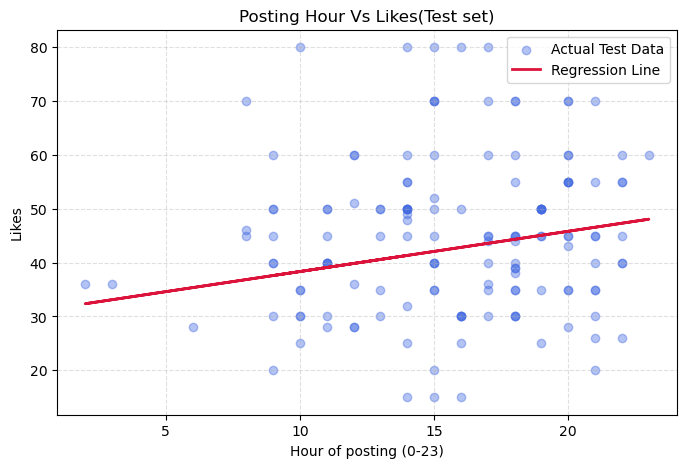

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(x_test,y_test,color="royalblue",alpha=0.4,label="Actual Test Data")
plt.plot(x_test,y_test_pred,color="crimson",linewidth=2,label="Regression Line")
plt.title("Posting Hour Vs Likes(Test set)")
plt.xlabel("Hour of posting (0-23)")
plt.ylabel("Likes")
plt.legend()
plt.grid(True,linestyle="--",alpha=0.4)
plt.show()



In [24]:
#The result here shows 

#Define Features (X) and Target (y)
x_2=df_sentiment[["Hashtags_count"]] #Double bracket keep X as 2D Dtafeame
y=df_sentiment["Likes"]

#Split Dataset into Training(80%) and Testing(20%)
x_2_train,x_2_test,y_train,y_test=train_test_split(
    x_2,y, test_size=0.2,random_state=30
)

#Fit Linear Regression Model
model=LinearRegression()
model.fit(x_2_train,y_train)

#Make Predictions the pred means predicts
y_train_pred=model.predict(x_2_train)
y_test_pred=model.predict(x_2_test)

#Model Evaluation Metrics
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

print(f"Intercept (beta_0):{model.intercept_:.4f}")
print(f"Slope (beta_1): {model.coef_[0]:.4f}\n")

print(f"Train MSE:{train_mse:4f} | Train R-squared: {train_r2:.4f}")
print(f"Test MSE:{test_mse:.4f} | Test R-squared:{test_r2:.4f}")

Intercept (beta_0):42.6855
Slope (beta_1): 0.0000

Train MSE:189.873721 | Train R-squared: 0.0000
Test MSE:231.8299 | Test R-squared:-0.0050


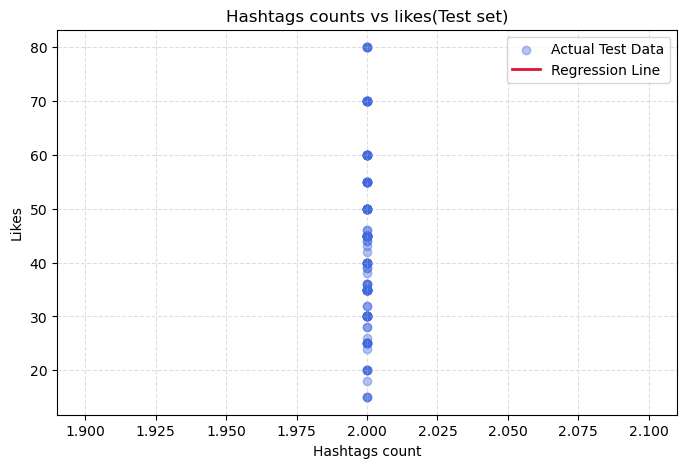

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(x_2_test,y_test,color="royalblue",alpha=0.4,label="Actual Test Data")
plt.plot(x_2_test,y_test_pred,color="crimson",linewidth=2,label="Regression Line")
plt.title("Hashtags counts vs likes(Test set)")
plt.xlabel("Hashtags count")
plt.ylabel("Likes")
plt.legend()
plt.grid(True,linestyle="--",alpha=0.4)
plt.show()

In [19]:

#Define Features (X) and Target (y)
x_3=df_sentiment[["Hour","Hashtags_count"]] #Double bracket keep X as 2D Dtafeame
y=df_sentiment["Likes"]

#Split Dataset into Training(80%) and Testing(20%)
x_3_train,x_3_test,y_train,y_test=train_test_split(
    x_3,y, test_size=0.2,random_state=30
)

#Fit Linear Regression Model
model=LinearRegression()
model.fit(x_3_train,y_train)

#Make Predictions the pred means predicts
y_train_pred=model.predict(x_3_train)
y_test_pred=model.predict(x_3_test)

#Model Evaluation Metrics
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

print(f"Intercept (beta_0):{model.intercept_:.4f}")
print(f"Slope (beta_1): {model.coef_[0]:.4f}\n")

print(f"Train MSE:{train_mse:4f} | Train R-squared: {train_r2:.4f}")
print(f"Test MSE:{test_mse:.4f} | Test R-squared:{test_r2:.4f}")

Intercept (beta_0):28.9875
Slope (beta_1): 0.8798

Train MSE:176.676963 | Train R-squared: 0.0695
Test MSE:250.5160 | Test R-squared:-0.0860


In [24]:
print(df_sentiment["Hashtags_count"].nunique())

1


In [23]:
df_sentiment[["Likes","Hour","Hashtags_count"]].corr()

,Likes,Hour,Hashtags_count
Likes,1.000000,0.195331,NaN
Hour,0.195331,1.000000,NaN
Hashtags_count,NaN,NaN,NaN


## Level 2 Task 2: Time Series Analysis

### Objective
Analyze the price behavior of one stock (**AAL**) by decomposing its closing price into trend, seasonal, and residual components, and by smoothing it with moving averages to identify trends.

### Method
- Isolated the AAL closing price, sorted by date, and set the date as the index.
- Reindexed to business days (`'B'`) and forward-filled gaps such as market holidays.
- Applied additive seasonal decomposition with a 5-day period (one trading week).
- Computed 20-day and 50-day simple moving averages.

### Results

| Component / Indicator | What it shows |
|---|---|
| Trend | Long multi-month swings between roughly $25$ and $55$ |
| Seasonal (5-day) | Tiny effect, about ±$0.02$ to $0.03$ |
| Residual | Mostly within ±$1$, with a few spikes up to about ±$2$ |
| 20-day MA | Follows price closely, filters out daily noise |
| 50-day MA | Smoother, highlights sustained multi-month direction |

### Interpretation

**1. Trend.** Between early 2014 and early 2018 the stock rose from about $25$ to a peak near $55$ in early 2015, then fell back through 2015 and the first half of 2016. It hit a low of about $25$ in mid-2016, then recovered steadily through 2017 to around $52$, with a pullback in mid-2017.

**2. Seasonality.** The weekly seasonal component is almost flat (about ±$0.03$ on a stock priced in the $25–55 range). The stock shows no meaningful day-of-week pattern, so weekly seasonality does not explain its price movement.

**3. Residuals.** Residuals are centered on zero with no obvious pattern. Most daily deviations are within about $1, and a handful of larger spikes may correspond to unusual events worth investigating.

**4. Moving averages.** The 20-day MA reacts faster, while the 50-day MA shows the broader direction. When the 20-day MA crosses above the 50-day MA (for example around late 2014 and late 2016), prices were entering strong upward phases. When it crosses below (for example around mid-2015), prices were entering a decline. Both averages lag the price, so crossovers confirm trends after they have started rather than predicting them.

### Limitations
- Only one stock (AAL) was analyzed, so findings do not generalize to the whole dataset.
- Missing `open`, `high`, and `low` values were filled with the overall column mean across all symbols. A per-stock method such as forward-fill or interpolation would be more appropriate.
- Forward-filling holidays assumes the price did not change on those days.
- Moving-average crossovers are descriptive. This analysis does not include backtesting.

### Conclusion
AAL's price is driven by multi-month trends and not by weekly seasonality. Moving averages describe those trends well, and the residual series is a possible starting point for spotting unusual price moves.


In [36]:
df_stock=pd.read_csv("Stock Prices Data Set.csv")
df_stock.fillna({"open":df_stock["open"].mean()},inplace=True)
df_stock.fillna({"high":df_stock["high"].mean()},inplace=True)
df_stock.fillna({"low":df_stock["low"].mean()},inplace=True)
df_stock["date"]=pd.to_datetime(df_stock["date"])
df_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  object        
 1   date    497472 non-null  datetime64[ns]
 2   open    497472 non-null  float64       
 3   high    497472 non-null  float64       
 4   low     497472 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 26.6+ MB


In [6]:
df_stock.isnull().sum()
df_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  object        
 1   date    497472 non-null  datetime64[ns]
 2   open    497472 non-null  float64       
 3   high    497472 non-null  float64       
 4   low     497472 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 26.6+ MB


In [16]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [10]:
print(df_stock['symbol'].unique()[:5])

['AAL' 'AAPL' 'AAP' 'ABBV' 'ABC']


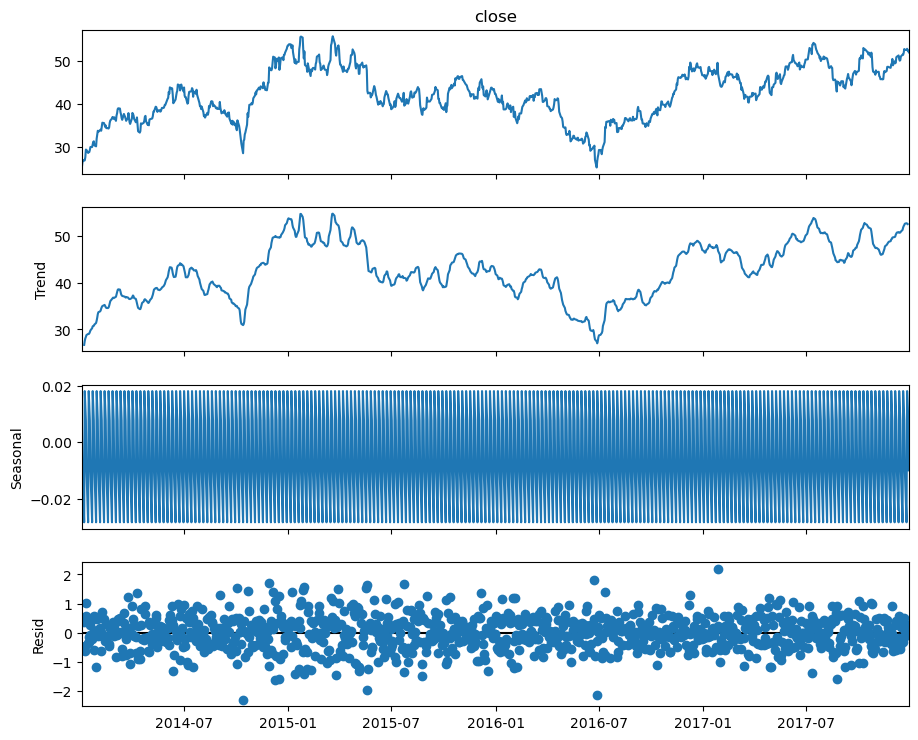

In [17]:
## Isolate One Stock and Format Dates
stock_df = df_stock[df_stock['symbol'] == 'AAL'].copy()
stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df = stock_df.sort_values('date')
stock_df.set_index('date', inplace=True)
time_series = stock_df['close']

#filling weekend gaps
time_series = time_series.asfreq('B')
time_series = time_series.ffill()

# Perform the Decomposition
result = seasonal_decompose(time_series, model='additive', period=5)
fig = result.plot()
fig.set_size_inches(10, 8)
plt.show()

In [18]:
stock_df['MA_20'] = stock_df['close'].rolling(window=20).mean()
stock_df['MA_50'] = stock_df['close'].rolling(window=50).mean()

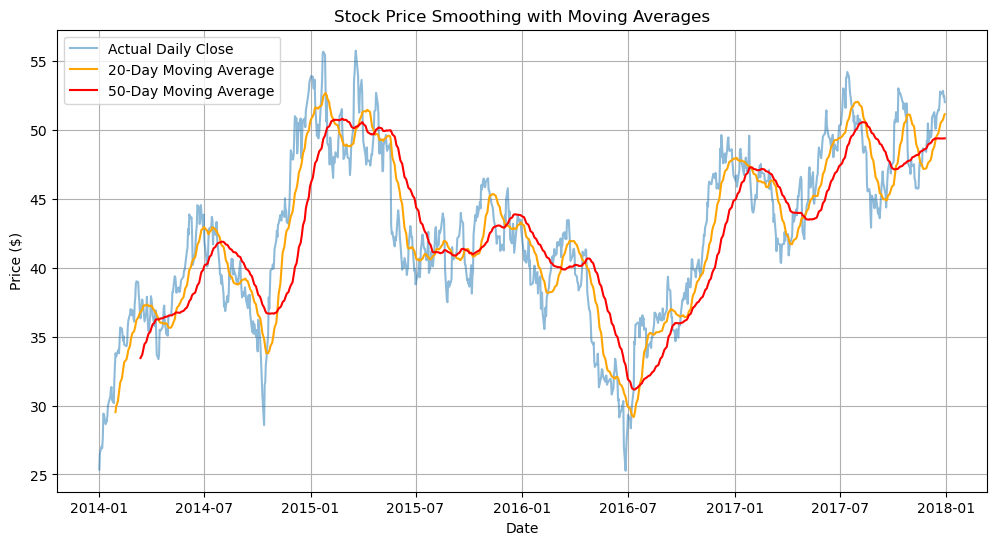

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(stock_df.index, stock_df['close'], label='Actual Daily Close', alpha=0.5)
plt.plot(stock_df.index, stock_df['MA_20'], label='20-Day Moving Average', color='orange')
plt.plot(stock_df.index, stock_df['MA_50'], label='50-Day Moving Average', color='red')
plt.title('Stock Price Smoothing with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

## Level 3 Task 3: K-Means Clustering

### Objective
Group AAL trading days by **closing price** and **trading volume** using K-Means clustering, and identify how many natural groups the data contains.

### Method
- Selected `close` and `volume` for the AAL stock.
- Standardized both features with `StandardScaler`, so volume (in millions) does not overwhelm price (in dollars).
- Ran K-Means for k = 1 to 10 and plotted inertia (Elbow Method).
- Fitted the final model with k = 3 and plotted the clusters.

### Results

| Cluster | Description | Closing price | Volume |
|---|---|---|---|
| Lower-price days | Majority of the low-price trading days | About $25–$45 | Mostly under about 20M, with a few spikes up to about 50M |
| Higher-price days | Majority of the high-price trading days | About $42–$56 | Mostly under about 20M, with a few spikes up to about 42M |
| Outlier | A single extreme-volume day | About $55 | About 138M |

*Cluster numbers and colors can change between runs, so the clusters are described by their characteristics.*

### Interpretation

**1. Choosing k.** The inertia curve drops sharply from k = 1 to k = 3 and then flattens gradually. There is no sharp elbow, but k = 3 is a reasonable choice, since adding more clusters gives smaller improvements.

**2. Price-based grouping.** Two main groups of trading days emerge, separated mainly by closing price, with the boundary around $42–45. The two groups overlap slightly in that range, so the split is a soft boundary and not a clean cut. Volume does not separate the two main groups, since both trade at similar volume levels.

**3. Outlier detection.** The third cluster contains only one trading day, with about 138 million shares traded at around $55, far above every other day. K-Means isolated this extreme-volume event, which shows that clustering can help detect unusual market activity.

### Limitations
- Only one stock (AAL) and only two features (price and volume) were used.
- One cluster holds a single point, so k = 3 is really "two regimes plus one outlier" and not three equal groups.
- The elbow is gradual, so the choice of k = 3 is a judgment call. A silhouette score would give a second check.
- K-Means is sensitive to outliers. The 138M-volume day affects how the clusters are formed.

### Conclusion
AAL's trading days divide mainly into lower-price and higher-price periods, and the clustering also isolates one extraordinary volume spike. For further analysis, try removing the outlier and re-clustering, adding features such as daily price range or moving averages, and comparing the results with a silhouette score.

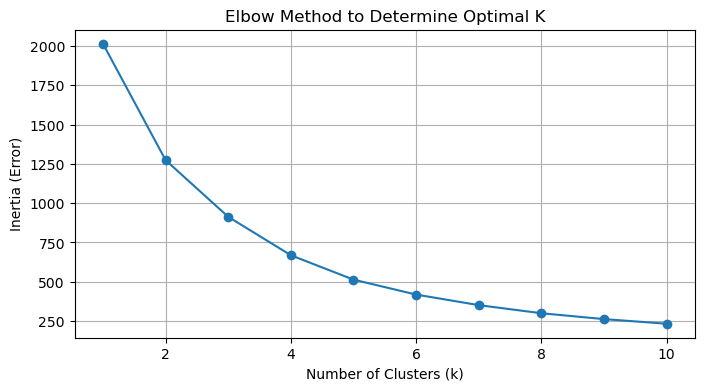

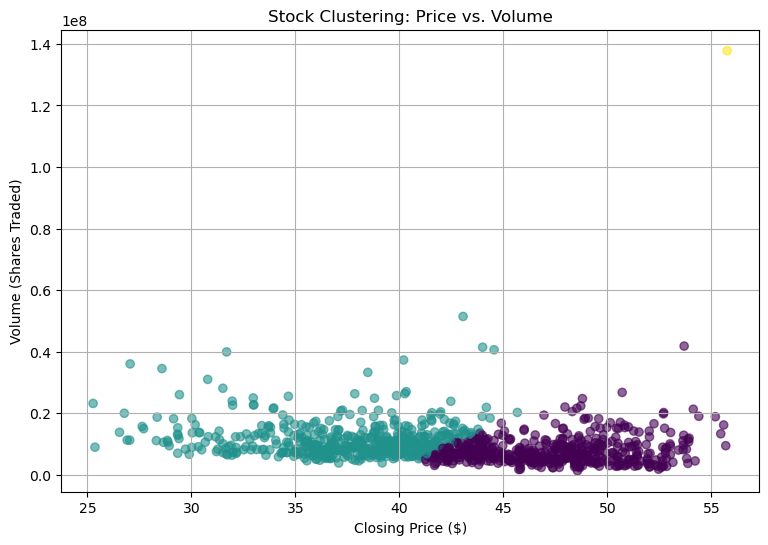

In [21]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Select the features you want to group
# Here we compare closing price against trading volume
features = stock_df[['close', 'volume']].dropna()

# 2. Standardize the features so volume doesn't dominate price
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 3. Find the optimal number of clusters using the Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Error)')
plt.grid(True)
plt.show()

# 4. Train the model with the chosen number of clusters (e.g., k=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
features['cluster'] = kmeans.fit_predict(scaled_features)

# 5. Visualize the clusters with a 2D Scatter Plot
plt.figure(figsize=(9, 6))
plt.scatter(
    features['close'],
    features['volume'],
    c=features['cluster'],
    cmap='viridis',
    alpha=0.6,
)
plt.title('Stock Clustering: Price vs. Volume')
plt.xlabel('Closing Price ($)')
plt.ylabel('Volume (Shares Traded)')
plt.grid(True)
plt.show()